<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file demonstrates the exploration of the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' after cleaning and WITHOUT consideration of complex network ideology just yet.  The primary goal is to establish statistically significant and strongly associated features with the target feature 'attack' which has 21 different tags to include benign tags which make up the majority of the dataset.  These will then be used for Machine-Learning and Neural Network model training, testing, and performance evaluation to establish a baseline for later comparison with models using just complex network ideology and later a mixture of the two.

---

### IMPORTANT NOTE:

I have not taken any cybersecurity courses nor have a background in it so I apologize if there are better alternatives that I do not implement or am unaware of.  I have a very basic level of understanding from reading threads, research papers, and definitions of terminology relevant in the field.  Though Subject-Matter-Expertise (SME) would be very helpful and valuable during this stage in my opinion, I'm aware that there's the inherent risk of implementing bias into the model causing a poorly performing model.  For this reason-and my lack of SME-I will heavily rely on statistical methods to determine what should and shouldn't be implemented into model training.

---

### GENERAL STATISTICAL APPLICATION:

Due to the non-binary nature of the target feature 'attack' (21 categorical tags), I intend to rely on Analysis of Variance (ANOVA) related statistical methodologies.  ANOVA is primarily used when statistically comparing more than one group of information to help determine statistical significance and associativity of information.  Given the nature of the dataset, there are two distinct categories of data to consider in relation to the target feature:
1. Categorical Data ('object' and 'str' dtypes)
2. Numerical Data ('int' and 'float' dtypes)

To determine the statistical significance (i.e. whether or not the p-value is less than some alpha value that is typically set to 0.05), for categorical data I will use the chi-squared test and for numerical data I will use Kruskal Wallis H-Test since data like <code>bytes</code> are likely to be not normally distributed.

However, statistical significance does not mean it correlates to the target variable, it just means that there's a fairly strong distribution of categorical data or linear association of numerical data to the feature name.  In other words, it should be effective for removing features with mathematical noise associated with them, but does not consider whether or not the feature actually is associated with the feature name (Think of a database intrusion, yes more throughput is going to be statistically significant in identifying this malicious activity, but throughput doesn't necessarily have a direct association to malicious activity in general).  For this reason, I want to also consider statistical methods to prove associativity of features to the target feature, thus for categorical data I will use Cramer's V test and for numerical data I will use a Mutual Information test.

Overall, the intended implementation of statistical analysis is as follows:
- Categorical Data
    - Statistical Significance (Mathematic strength of information)
        - Chi-squared testing
        - Is significant if <code>p-value<=0.05</code>
    - Associativity to Target (Actual relationship to target)
        - Cramer's V
        - Strongly associated to target if <code>association>=0.50</code>
        - Mildly associated to target if <code>association>=0.33</code>
        - Weakly associated to target if <code>association>=0.10</code>
        - The above categories are to consider the very large depth of information representative in the dataset where it is likely that most things are only associated to a few specific target variables
- Numerical Data
    - Statistical Significance (Mathematic strength of information)
        - Kruskal Wallis H-Test
        - Is significant if <code>p-value<=0.05</code>
    - Associativity to Target (Actual relationship to target)
        - Mutual Information Test
        - Strongly associated to target if <code>association>=0.50</code>
        - Mildly associated to target if <code>association>=0.33</code>
        - Weakly associated to target if <code>association>=0.10</code>
        - The above categories are to consider the very large depth of information representative in the dataset where it is likely that most things are only associated to a few specific target variables
- If any feature is statistically significant <b>AND</b> has some sort of associative significance, then it will be used for ML and NN training

---

### EXPLORATION SUMMARY:

- stuff

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
import explore_normal_data as eND
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [2]:
# Read in the dataset
df = pd.read_parquet('datasets/clean_short.parquet')

The dataset used is the `clean_short.parquet` which is 5% of the full dataset:
- Rows: 3,799,095
- Columns: 46
- Target: `attack` (21 Unique tags, distribution visualized below data dictionary)

| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **ipv4_src_addr** | `str` | 192.168.1.31, 192.168.1.34, 192.168.100.150 | The IPv4 address of the source host initiating the flow. |
| **l4_src_port** | `int64` | 38428, 37921, 39164 | The transport layer (Layer 4) source port number. |
| **ipv4_dst_addr** | `str` | 192.168.35.45, 192.168.1.49, 192.168.100.3 | The IPv4 address of the destination host receiving the flow. |
| **l4_dst_port** | `int64` | 443, 83, 80 | The transport layer (Layer 4) destination port number. |
| **protocol** | `int64` | 6, 17, 90 | The IP protocol number (e.g., 6 for TCP, 17 for UDP). |
| **l7_proto** | `float64` | 91.0, 0.0, 188.0 | The detected Application Layer (Layer 7) protocol (e.g., HTTP, DNS). |
| **in_bytes** | `int64` | 44, 56, 48 | Incoming bytes transferred from source to destination. |
| **in_pkts** | `int64` | 1, 2, 14 | Total number of incoming packets from source to destination. |
| **out_bytes** | `int64` | 0, 40, 764 | Outgoing bytes transferred from destination back to source. |
| **out_pkts** | `int64` | 0, 1, 9 | Total number of outgoing packets from destination back to source. |
| **tcp_flags** | `int64` | 2, 0, 22 | Cumulative bitwise-OR of all TCP flags observed in the flow. |
| **client_tcp_flags** | `int64` | 2, 0, 219 | Bitwise-OR of TCP flags sent specifically by the client (source). |
| **server_tcp_flags** | `int64` | 0, 20, 94 | Bitwise-OR of TCP flags sent specifically by the server (destination). |
| **flow_duration_milliseconds** | `int64` | 0, 4294013, 4294936 | The total elapsed time of the flow measured in milliseconds. |
| **duration_in** | `int64` | 0, 954, 719 | Duration of the active flow in the incoming direction. |
| **duration_out** | `int64` | 0, 16, 9 | Duration of the active flow in the outgoing direction. |
| **min_ttl** | `int64` | 0, 64, 100 | Minimum Time-to-Live (TTL) value observed in the flow. |
| **max_ttl** | `int64` | 0, 64, 100 | Maximum Time-to-Live (TTL) value observed in the flow. |
| **longest_flow_pkt** | `int64` | 44, 28, 48 | The size (in bytes) of the largest packet observed in the flow. |
| **shortest_flow_pkt** | `int64` | 44, 28, 40 | The size (in bytes) of the smallest packet observed in the flow. |
| **min_ip_pkt_len** | `int64` | 0, 40, 68 | The minimum IP packet length observed. |
| **max_ip_pkt_len** | `int64` | 44, 28, 48 | The maximum IP packet length observed. |
| **src_to_dst_second_bytes** | `float64` | 44.0, 2828.0, 48.0 | Average bytes per second sent from source to destination. |
| **dst_to_src_second_bytes** | `float64` | 0.0, 40.0, 764.0 | Average bytes per second sent from destination to source. |
| **retransmitted_in_bytes** | `int64` | 0, 140, 578 | Number of incoming bytes that were retransmitted. |
| **retransmitted_in_pkts** | `int64` | 0, 1, 2 | Number of incoming packets that were retransmitted. |
| **retransmitted_out_bytes** | `int64` | 0, 1419, 4820 | Number of outgoing bytes that were retransmitted. |
| **retransmitted_out_pkts** | `int64` | 0, 4, 6 | Number of outgoing packets that were retransmitted. |
| **src_to_dst_avg_throughput** | `int64` | 352000, 224000, 384000 | Average bits per second sent from source to destination. |
| **dst_to_src_avg_throughput** | `int64` | 0, 320000, 6112000 | Average bits per second sent from destination to source. |
| **num_pkts_up_to_128_bytes** | `int64` | 1, 2, 19 | Count of packets in the flow with size ≤ 128 bytes. |
| **num_pkts_128_to_256_bytes** | `int64` | 0, 1, 2 | Count of packets in the flow with size between 128 and 256 bytes. |
| **num_pkts_256_to_512_bytes** | `int64` | 0, 2, 1 | Count of packets in the flow with size between 256 and 512 bytes. |
| **num_pkts_512_to_1024_bytes** | `int64` | 0, 1, 2 | Count of packets in the flow with size between 512 and 1024 bytes. |
| **num_pkts_1024_to_1514_bytes** | `int64` | 0, 1, 3 | Count of packets in the flow with size between 1024 and 1514 bytes. |
| **tcp_win_max_in** | `int64` | 1024, 0, 4096 | Maximum TCP window size observed for incoming traffic. |
| **tcp_win_max_out** | `int64` | 0, 64000, 29200 | Maximum TCP window size observed for outgoing traffic. |
| **icmp_type** | `int64` | 0, 35840, 16896 | ICMP message type and code encoded as a decimal. |
| **icmp_ipv4_type** | `int64` | 0, 140, 66 | Specific ICMP Type field value for IPv4 traffic. |
| **dns_query_id** | `int64` | 0, 33190, 30688 | The transaction ID for DNS queries. |
| **dns_query_type** | `int64` | 0, 28, 1 | The type of DNS record requested (e.g., 1 for A, 28 for AAAA). |
| **dns_ttl_answer** | `int64` | 0, 60, 20 | The Time-to-Live (TTL) value from the DNS response. |
| **ftp_command_ret_code** | `float64` | 0.0, 125.0, 230.0 | The three-digit return code from an FTP command. |
| **label** | `int64` | 1, 0 | Binary indicator of traffic: 0 for Benign, 1 for Attack. |
| **attack** | `str` | scanning, benign, ddos, ... | Categorical name of the specific attack type (21 unique tags). |
| **dataset** | `str` | nf-ton-iot-v2, nf-bot-iot-v2, ... | The original source dataset from which the flow was extracted. |

/Users/manupfool/Desktop/University_of_Denver/inprogress_courses/COMP3703/final/explore_normal_data.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=labels, palette='viridis')


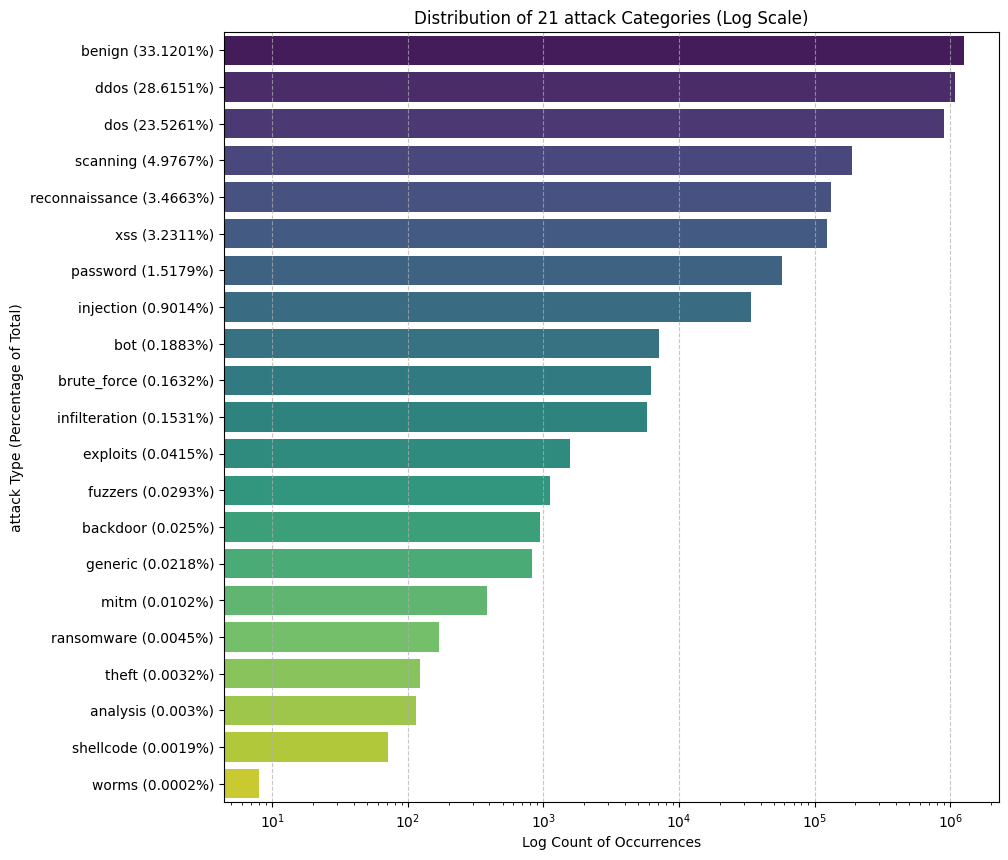

In [4]:
# Visualize target distribution
eND.vis_target_distribution(df)

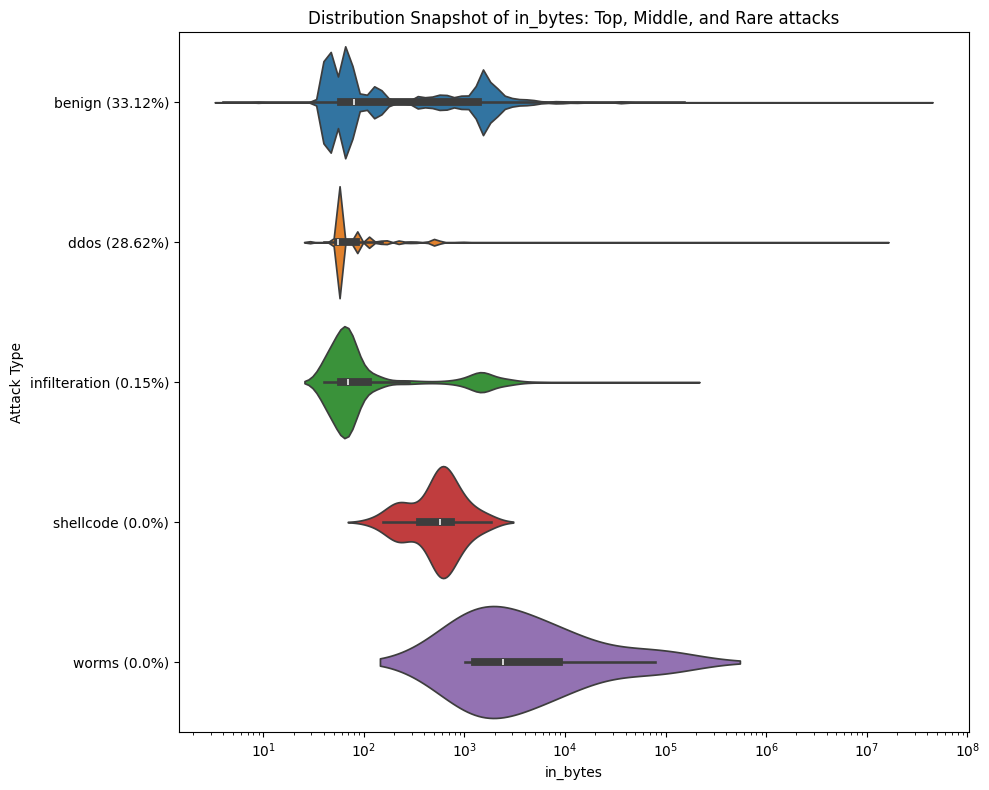

In [3]:
eND.vis_numerical(df, 'in_bytes')

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>